# Intensity Transformations & Filtering Spatial Domain

## Thresholding

Threshold value: 0


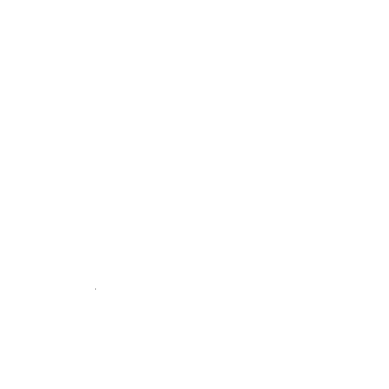

Threshold value: 50


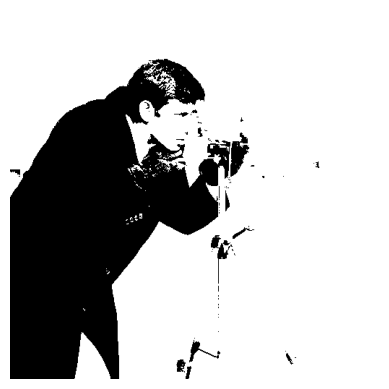

Threshold value: 100


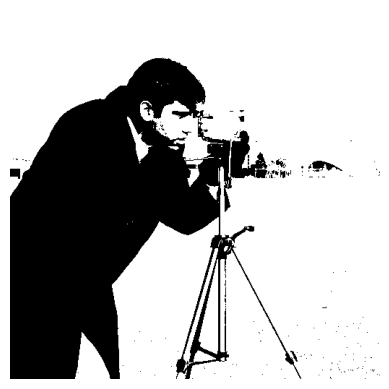

Threshold value: 150


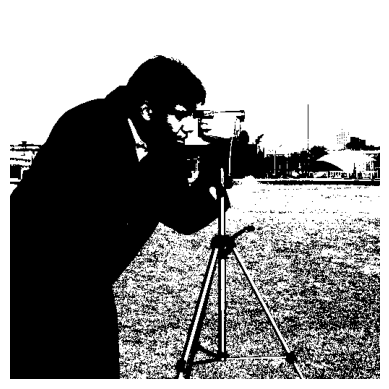

Threshold value: 200


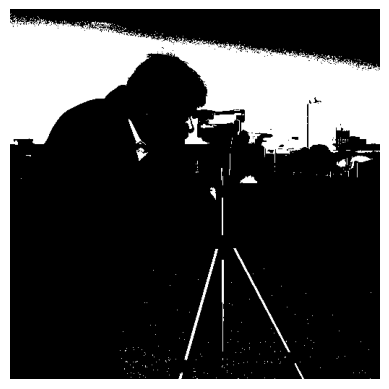

In [16]:
from skimage import data
import cv2
import matplotlib.pyplot as plt

img = data.camera()

threshold_values = [0, 50, 100, 150, 200]

for threshold_value in threshold_values:
    _, thresh_img = cv2.threshold(
        img, threshold_value, 255, cv2.THRESH_BINARY
    )

    print(f"Threshold value: {threshold_value}")
    plt.imshow(thresh_img, cmap="gray")
    plt.axis("off")
    plt.show()

Original Image: 


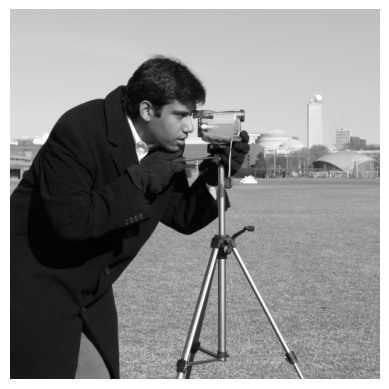

In [19]:
print("Original Image: ")
plt.imshow(img, cmap="gray")
plt.axis("off")
plt.show()

## Histograms

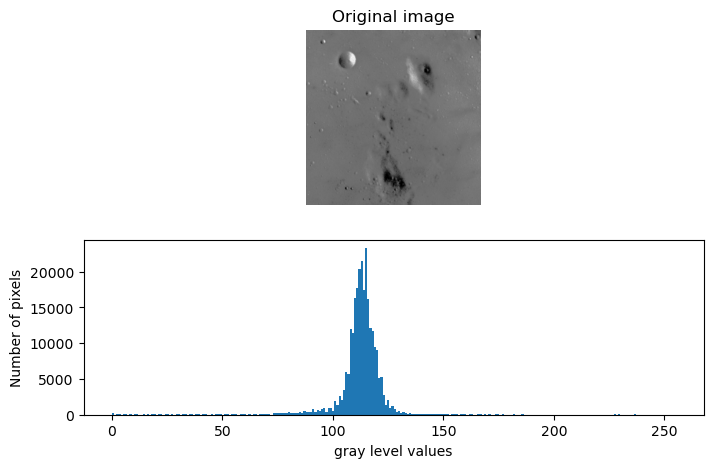

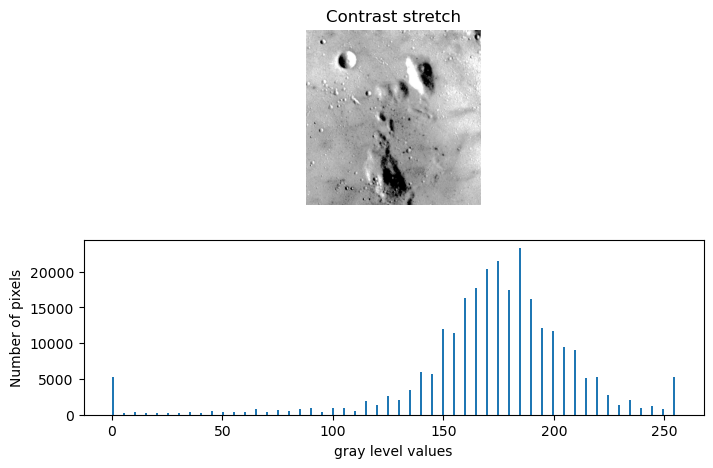

In [9]:
# Task#2: Histogram Processing

# Step#1: Load necessary libraries
import matplotlib
import matplotlib.pyplot as plt
import numpy as np

from skimage import data
from skimage import exposure

# Step#2: Load moon image
img = data.moon()

# Step#3: Rescale intensity values to include all the intensities that fall within the 2nd and 98th percentiles
# Contrast stretching
p2, p98 = np.percentile(img, (2, 98))
img_rescale = exposure.rescale_intensity(img, in_range=(p2, p98))

# Step#4: Display the image with its histogram of (step#2)  and (step#3)
fig = plt.figure(figsize=(8, 5))
fig.add_subplot(2, 1, 1)
plt.imshow(img, cmap = 'gray')
plt.axis('off')
plt.title('Original image')

fig.add_subplot(2, 1, 2)
plt.hist(img.flat, bins = 256, range=(0, 255))
plt.xlabel('gray level values')
plt.ylabel('Number of pixels')
plt.show()

fig = plt.figure(figsize=(8, 5))
fig.add_subplot(2, 1, 1)
plt.imshow(img_rescale, cmap = 'gray')
plt.axis('off')
plt.title('Contrast stretch')

fig.add_subplot(2, 1, 2)
plt.hist(img_rescale.flat, bins = 256, range=(0, 255))
plt.xlabel('gray level values')
plt.ylabel('Number of pixels')
plt.show()

# Tasks:

Task1: Using the same ‘moon image’ Rescale intensity values to include all the intensities that fall within the 3nd and 80th percentiles, and plot the histogram

Task2: Using the same ‘moon image’ and the exposure.equalize_hist function, display the image and the histogram of the image after flattening the histogram.

Task3: Use the rocket (as reference) and chelsea images (from skimage.data) and implement histogram matching


## Task1: Contract Stretching

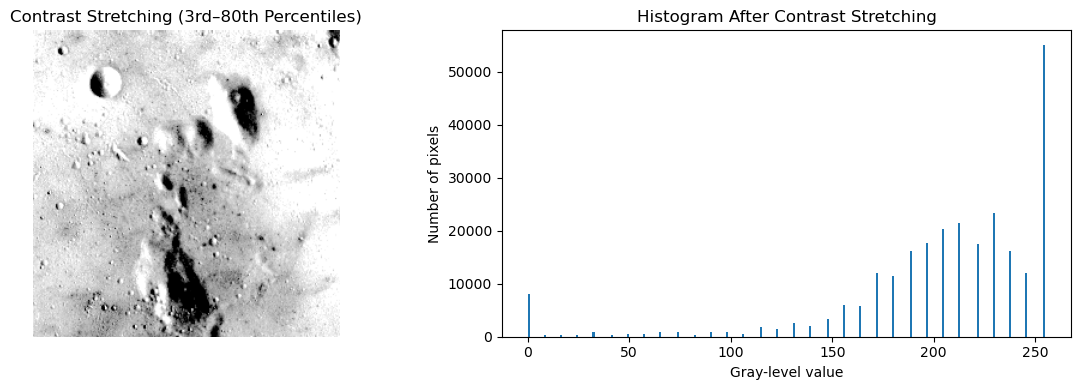

In [20]:
# Load the moon image
img = data.moon()

# Find the intensity values at the 3rd and 80th percentiles
p3, p80 = np.percentile(img, (3, 80))

# Apply contrast stretching
img_rescale = exposure.rescale_intensity(
    img, in_range=(p3, p80)
)

# Display the image and its histogram
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].imshow(img_rescale, cmap="gray")
axes[0].set_title("Contrast Stretching (3rd–80th Percentiles)")
axes[0].axis("off")

axes[1].hist(
    img_rescale.ravel(),
    bins=256,
    range=(0, 255)
)
axes[1].set_title("Histogram After Contrast Stretching")
axes[1].set_xlabel("Gray-level value")
axes[1].set_ylabel("Number of pixels")

plt.tight_layout()
plt.show()

## Task2 : Histogram Equalization

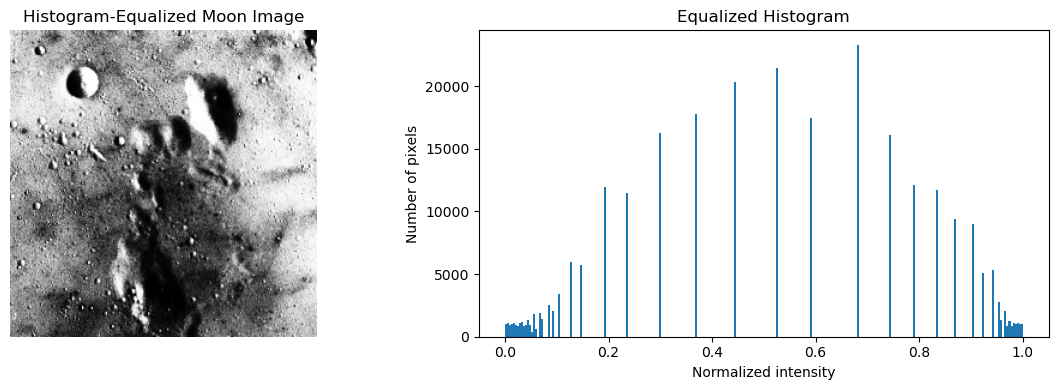

In [21]:
# Load the moon image
img = data.moon()

# Apply histogram equalization
img_equalized = exposure.equalize_hist(img)

# Display the equalized image and its histogram
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].imshow(img_equalized, cmap="gray")
axes[0].set_title("Histogram-Equalized Moon Image")
axes[0].axis("off")

# equalize_hist returns values between 0 and 1
axes[1].hist(
    img_equalized.ravel(),
    bins=256,
    range=(0, 1)
)
axes[1].set_title("Equalized Histogram")
axes[1].set_xlabel("Normalized intensity")
axes[1].set_ylabel("Number of pixels")

plt.tight_layout()
plt.show()

## Task3: Histogram Matching

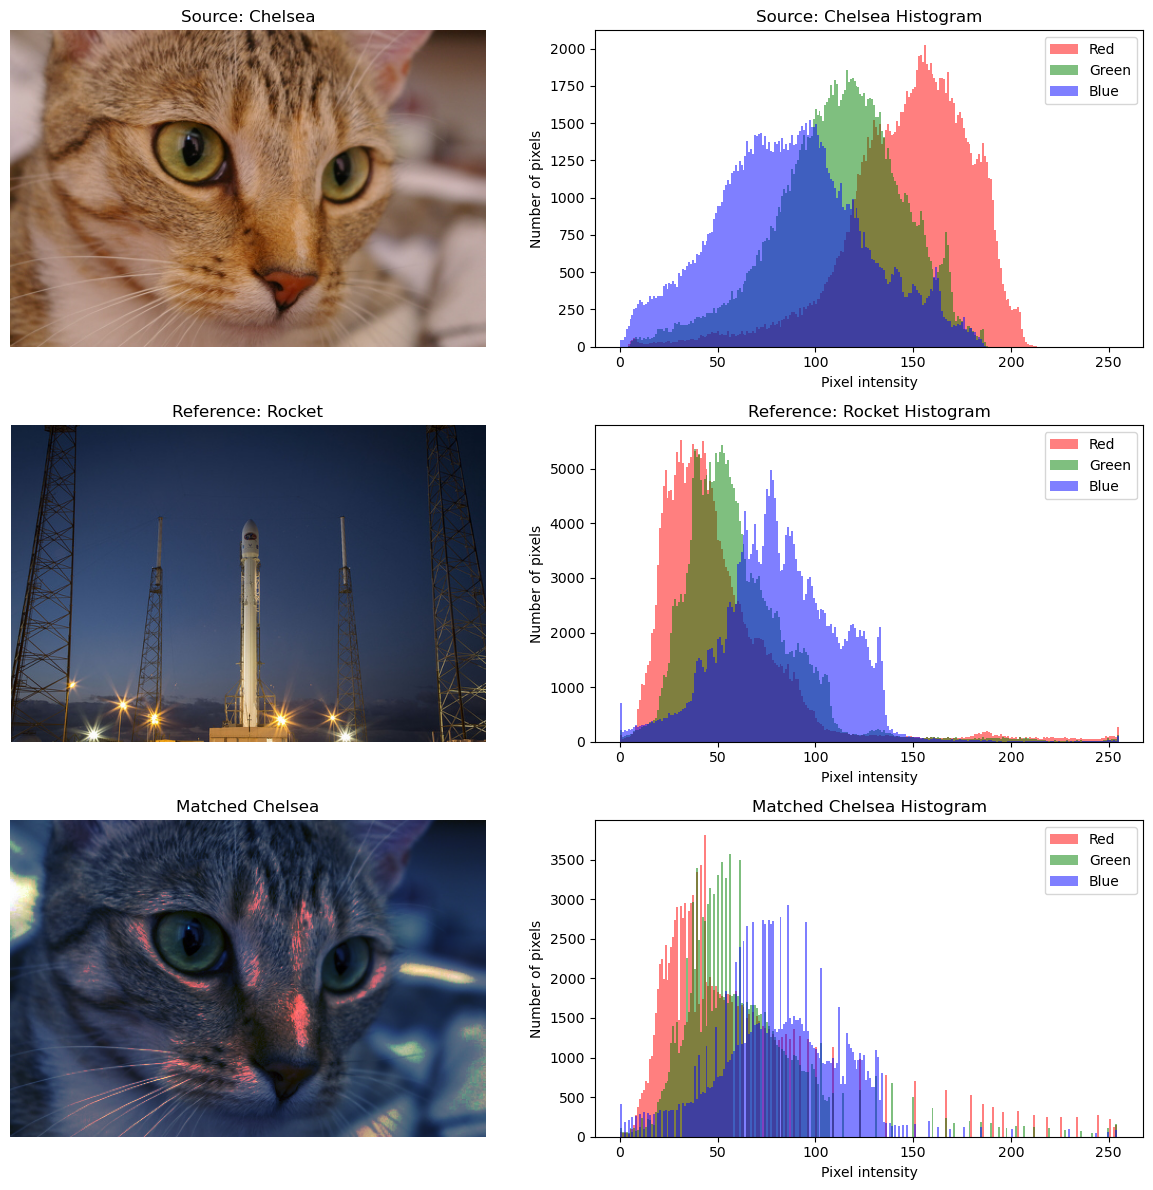

In [23]:
# Task 3: Histogram matching with histogram plots

# Load the images
source = data.chelsea()
reference = data.rocket()

# Match Chelsea's histogram to the rocket image
matched = exposure.match_histograms(
    source,
    reference,
    channel_axis=-1
)

images = [source, reference, matched]
titles = [
    "Source: Chelsea",
    "Reference: Rocket",
    "Matched Chelsea"
]

colors = ["red", "green", "blue"]

# Three rows: each image followed by its RGB histogram
fig, axes = plt.subplots(3, 2, figsize=(12, 12))

for row, (image, title) in enumerate(zip(images, titles)):

    # Display the image
    axes[row, 0].imshow(image)
    axes[row, 0].set_title(title)
    axes[row, 0].axis("off")

    # Plot the histogram of each RGB channel
    for channel, color in enumerate(colors):
        axes[row, 1].hist(
            image[:, :, channel].ravel(),
            bins=256,
            range=(0, 255),
            color=color,
            alpha=0.5,
            label=color.capitalize()
        )

    axes[row, 1].set_title(f"{title} Histogram")
    axes[row, 1].set_xlabel("Pixel intensity")
    axes[row, 1].set_ylabel("Number of pixels")
    axes[row, 1].legend()

plt.tight_layout()
plt.show()